In [511]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from SynthSpread.spreadviewer_class import SpreadSingle, SpreadViewerData, norm_coeff
#from Database.TPData import TPData, TPDataDa, TPDataAssembly

from Strategies.LeadLag_strategy.backtest_class import BacktestLL
from Strategies.LeadLag_strategy.strategy_class import StrategyLL, VolumeClass
tol=(1e-1)/2

In [512]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [513]:
#5	17	0.1	1.00	-0.75	

In [514]:
#10	9	0.2	30	0.1	0.3	0.5	-0.4

In [515]:
max_secs_between_trades=60
cluster_trade_num_threshold=5
min_price_movement=0.05

burnout_period=30
stop_profit=0.1
makeagg_ratio=0.3

take_profit=0.5
stop_loss=-0.4

br_fee = 0.0175
closing_mode='Martinovo_zatvaranie'

# Test part - Nov, Dec (here it was calibrated)

## Data preparation

In [516]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_test_short.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_dew1_test_short.csv',
                    parse_dates=['datetime']).reset_index()

In [517]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [518]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [519]:
# data_lag=data_lag.drop(index=177223).reset_index()
# del data_lag['level_0']

In [520]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
113,113,2023-11-01 09:01:03.516218423,80.25,5.0,80.25,81.26,80.755,0,90.516218
114,114,2023-11-01 09:01:04.000000000,NaN,NaN,80.00,81.26,80.630,1,0.483782
115,115,2023-11-01 09:01:12.607000113,80.00,10.0,80.00,81.26,80.630,0,8.607000
116,116,2023-11-01 09:01:13.000000000,NaN,NaN,80.00,82.00,81.000,1,0.393000
117,117,2023-11-01 09:01:14.956530333,80.00,10.0,80.00,82.00,81.000,0,1.956530


In [521]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
74,74,2023-11-01 09:00:08.017724752,96.45,2.0,96.45,96.75,96.600,0
75,75,2023-11-01 09:00:08.017784357,96.45,3.0,96.45,96.75,96.600,0
76,76,2023-11-01 09:00:54.762271643,96.25,1.0,96.25,96.35,96.300,0
77,77,2023-11-01 09:00:56.679996014,96.25,1.0,96.25,96.35,96.300,0
78,78,2023-11-01 09:01:30.349739313,96.07,1.0,96.01,96.08,96.045,1


## Parameters and calculations

In [522]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['max_secs_between_trades'] = max_secs_between_trades
param_dict['cluster_trade_num_threshold'] = cluster_trade_num_threshold
param_dict['min_price_movement'] = min_price_movement

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio

vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [523]:
from bokeh.plotting import figure, show, output_file
from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
import pandas as pd

# Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# Convert 'timestamp' to datetime if not already
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Assign color based on 'position' value
df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
df['price_level']=df['price_level']-df['position']*br_fee

# Create ColumnDataSources
source_df = ColumnDataSource(df)
source_lead = ColumnDataSource(data_lead)
source_lag = ColumnDataSource(data_lag)

# Create a figure with dynamic sizing
p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# Adjust y-axes ranges
p.extra_y_ranges = {
   "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
   "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
}

# Add left and right y-axes
p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# Plotting with hover tools
lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# Define hover tools for each glyph
hover_position = HoverTool(renderers=[position_circles], tooltips=[
    ("Timestamp", "@timestamp{%F %T}"),
    ("Price Level", "@price_level"),
    ("Position", "@position"),
    ("Color", "@color"),
], formatters={'@timestamp': 'datetime'})

hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
    ("Datetime", "@datetime{%F %T}"),
    ("Lead Price", "@trd_price"),
], formatters={'@datetime': 'datetime'})

hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
    ("Datetime", "@datetime{%F %T}"),
    ("Lag Price", "@trd_price"),
], formatters={'@datetime': 'datetime'})

# Add hover tools to the plot
p.add_tools(hover_position, hover_lead, hover_lag)

# Customize plot
p.legend.location = "top_left"
p.xaxis.axis_label = "Datetime"
p.yaxis.axis_label = "Price Level"

# Show the plot
show(p)

<Axes: >

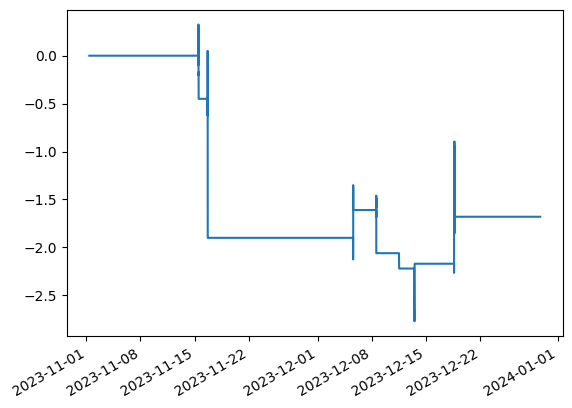

In [524]:
xx.plot()

In [525]:
#df[0:50]

In [526]:
xx[-1:]

2023-12-29 17:58:13   -1.68
dtype: float64

# OOT part - Jan, Feb 

## Data preparation

In [527]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_oot_short.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_dew1_oot_short.csv',
                    parse_dates=['datetime']).reset_index()

In [528]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [529]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [530]:
#data_lag=data_lag.drop(index=177223).reset_index()
#del data_lag['level_0']

In [531]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
259,259,2024-01-02 09:00:07.000000000,NaN,NaN,108.00,109.99,108.995,1,198.000000
260,260,2024-01-02 09:00:48.045818806,109.99,1.0,108.00,109.99,108.995,1,41.045819
261,261,2024-01-02 09:00:49.000000000,NaN,NaN,108.00,110.00,109.000,1,0.954181
262,262,2024-01-02 09:00:53.800404072,110.00,5.0,108.00,110.00,109.000,1,4.800404
263,263,2024-01-02 09:00:54.000000000,NaN,NaN,107.51,111.99,109.750,1,0.199596


In [532]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
1,1,2024-01-02 09:00:00.907744884,91.97,2.0,91.97,92.50,92.235,0
2,2,2024-01-02 09:00:40.962116718,92.00,3.0,91.96,92.49,92.225,0
3,3,2024-01-02 09:00:41.104269743,91.97,1.0,91.96,92.49,92.225,0
4,4,2024-01-02 09:00:41.159442425,92.00,1.0,91.96,92.49,92.225,0
5,5,2024-01-02 09:00:50.746176004,91.96,3.0,91.96,92.00,91.980,0


## Parameters and calculations

In [533]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['max_secs_between_trades'] = max_secs_between_trades
param_dict['cluster_trade_num_threshold'] = cluster_trade_num_threshold
param_dict['min_price_movement'] = min_price_movement

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio

vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [534]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# # Convert 'timestamp' to datetime if not already
# df['timestamp'] = pd.to_datetime(df['timestamp'])

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
# df['price_level']=df['price_level']-df['position']*br_fee

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

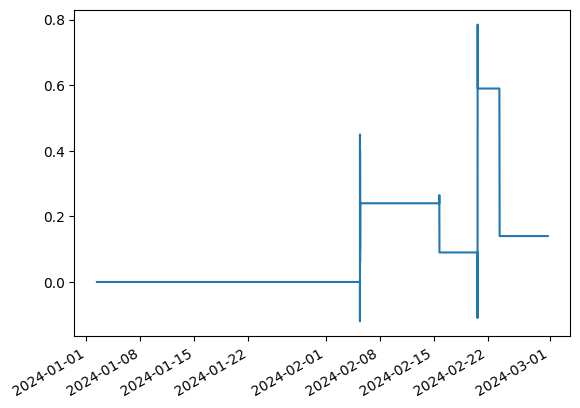

In [535]:
xx.plot()

In [536]:
#df[0:50]

In [537]:
xx[-1:]

2024-02-29 17:59:32    0.14
dtype: float64

# OOT part - Mar,Apr

## Data preparation

In [538]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_oot_mar_apr.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_dew1_oot_mar_apr.csv',
                    parse_dates=['datetime']).reset_index()

In [539]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [540]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [541]:
#data_lag=data_lag.drop(index=177223).reset_index()
#del data_lag['level_0']

In [542]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
122,122,2024-03-01 09:02:21.184999943,69.0,5.0,68.25,69.00,68.625,1,149.185
123,123,2024-03-01 09:02:21.197000027,69.0,25.0,68.25,69.00,68.625,1,0.012
124,124,2024-03-01 09:02:22.000000000,NaN,NaN,68.25,69.25,68.750,1,0.803
125,125,2024-03-01 09:02:27.000000000,NaN,NaN,68.26,69.25,68.755,1,5.000
126,126,2024-03-01 09:02:29.000000000,NaN,NaN,68.29,69.25,68.770,1,2.000


In [543]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
15,15,2024-03-01 09:00:09.338750124,56.41,2.0,56.41,56.61,56.510,0
16,16,2024-03-01 09:03:07.821218967,56.65,1.0,56.47,56.65,56.560,1
17,17,2024-03-01 09:03:07.821283579,56.70,5.0,56.47,56.65,56.560,1
18,18,2024-03-01 09:03:08.110189915,56.73,1.0,56.49,56.65,56.570,1
19,19,2024-03-01 09:03:14.834126711,56.90,1.0,56.72,56.89,56.805,1


## Parameters and calculations

In [544]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['max_secs_between_trades'] = max_secs_between_trades
param_dict['cluster_trade_num_threshold'] = cluster_trade_num_threshold
param_dict['min_price_movement'] = min_price_movement

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio

vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [545]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# # Convert 'timestamp' to datetime if not already
# df['timestamp'] = pd.to_datetime(df['timestamp'])
# df['price_level']=df['price_level']-df['position']*br_fee

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

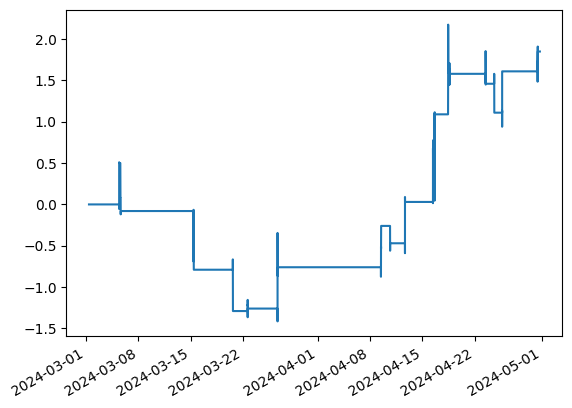

In [546]:
xx.plot()

In [547]:
#df[0:50]

In [548]:
xx[-1:]

2024-04-30 17:56:13    1.85
dtype: float64

# OOT part - May, Jun

## Data preparation

In [549]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_oot_may_june.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_dew1_oot_may_june.csv',
                    parse_dates=['datetime']).reset_index()

In [550]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [551]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [552]:
#data_lag=data_lag.drop(index=177223).reset_index()
#del data_lag['level_0']

In [553]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
16,16,2024-05-01 09:01:34,NaN,NaN,62.0,63.00,62.500,1,443.0
17,17,2024-05-01 09:01:41,NaN,NaN,61.0,63.00,62.000,1,7.0
18,18,2024-05-01 09:01:48,NaN,NaN,61.0,62.75,61.875,1,7.0
19,19,2024-05-01 09:02:36,NaN,NaN,61.5,62.75,62.125,1,48.0
20,20,2024-05-01 09:25:23,NaN,NaN,62.0,62.75,62.375,1,1367.0


In [554]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
35,35,2024-05-02 09:02:02.465197325,65.81,2.0,65.81,66.15,65.980,0
36,36,2024-05-02 09:03:31.473956823,66.00,1.0,65.75,65.99,65.870,1
37,37,2024-05-02 09:03:31.575801849,66.00,1.0,65.75,65.99,65.870,1
38,38,2024-05-02 09:03:32.014014244,65.99,1.0,65.75,65.99,65.870,1
39,39,2024-05-02 09:04:00.009787560,65.99,1.0,65.76,65.95,65.855,1


## Parameters and calculations

In [555]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['max_secs_between_trades'] = max_secs_between_trades
param_dict['cluster_trade_num_threshold'] = cluster_trade_num_threshold
param_dict['min_price_movement'] = min_price_movement

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio

vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [556]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# # Convert 'timestamp' to datetime if not already
# df['timestamp'] = pd.to_datetime(df['timestamp'])

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
# df['price_level']=df['price_level']-df['position']*br_fee

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

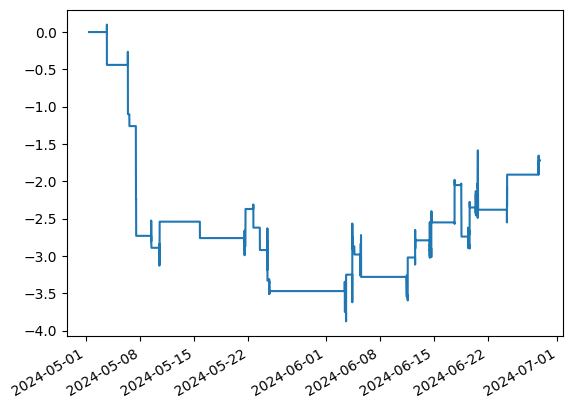

In [557]:
xx.plot()

In [558]:
#df[0:50]

In [559]:
xx[-1:]

2024-06-28 17:59:59   -1.72
dtype: float64

# Production check

## Data preparation

In [560]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_production_sample.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_production_sample.csv',
                    parse_dates=['datetime']).reset_index()

In [561]:
data_lead['datetime'] = pd.to_datetime(data_lead['datetime'], errors='coerce')
data_lag['datetime'] = pd.to_datetime(data_lag['datetime'], errors='coerce')

In [562]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [563]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [564]:
#data_lag=data_lag.drop(index=177223).reset_index()
#del data_lag['level_0']

In [565]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
193,193,2024-07-02 09:00:03,NaN,NaN,81.00,81.75,81.375,1,98.0
194,194,2024-07-02 09:00:05,NaN,NaN,81.01,81.75,81.380,1,2.0
195,195,2024-07-02 09:00:06,NaN,NaN,81.00,81.75,81.375,1,1.0
196,196,2024-07-02 09:00:12,NaN,NaN,81.01,81.75,81.380,1,6.0
197,197,2024-07-02 09:00:15,NaN,NaN,81.00,81.70,81.350,1,3.0


In [566]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
55,55,2024-07-02 09:00:00.294484854,75.88,1.0,75.88,75.96,75.920,0
56,56,2024-07-02 09:00:10.419681549,75.79,1.0,75.79,75.88,75.835,0
57,57,2024-07-02 09:00:12.289536476,75.75,1.0,75.75,75.86,75.805,0
58,58,2024-07-02 09:00:12.480537653,75.71,1.0,75.75,75.86,75.805,0
59,59,2024-07-02 09:00:24.580563545,75.69,1.0,75.75,75.85,75.800,0


## Parameters and calculations

In [567]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['max_secs_between_trades'] = max_secs_between_trades
param_dict['cluster_trade_num_threshold'] = cluster_trade_num_threshold
param_dict['min_price_movement'] = min_price_movement

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio

vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [568]:
from bokeh.plotting import figure, show, output_file
from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
import pandas as pd

# As

# Assign color based on 'position' value
df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
df['price_level']=df['price_level']-df['position']*br_fee

# Create ColumnDataSources
source_df = ColumnDataSource(df)
source_lead = ColumnDataSource(data_lead)
source_lag = ColumnDataSource(data_lag)

# Create a figure with dynamic sizing
p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# Adjust y-axes ranges
p.extra_y_ranges = {
   "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
   "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
}

# Add left and right y-axes
p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# Plotting with hover tools
lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# Define hover tools for each glyph
hover_position = HoverTool(renderers=[position_circles], tooltips=[
    ("Timestamp", "@timestamp{%F %T}"),
    ("Price Level", "@price_level"),
    ("Position", "@position"),
    ("Color", "@color"),
], formatters={'@timestamp': 'datetime'})

hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
    ("Datetime", "@datetime{%F %T}"),
    ("Lead Price", "@trd_price"),
], formatters={'@datetime': 'datetime'})

hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
    ("Datetime", "@datetime{%F %T}"),
    ("Lag Price", "@trd_price"),
], formatters={'@datetime': 'datetime'})

# Add hover tools to the plot
p.add_tools(hover_position, hover_lead, hover_lag)

# Customize plot
p.legend.location = "top_left"
p.xaxis.axis_label = "Datetime"
p.yaxis.axis_label = "Price Level"

# Show the plot
show(p)

<Axes: >

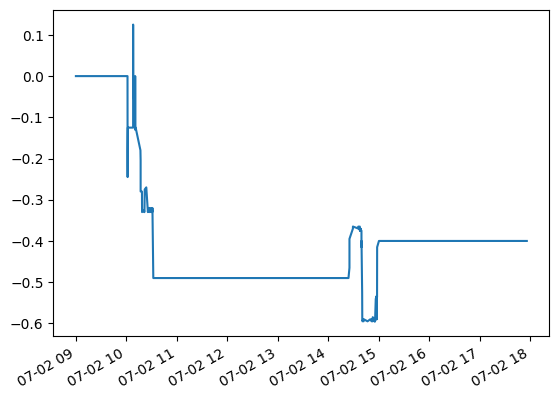

In [569]:
xx.plot()

In [570]:
#df[0:50]

In [571]:
xx[-1:]

2024-07-02 17:56:08   -0.4
dtype: float64

In [572]:
xx

2024-07-02 09:00:03.000000000    0.0
2024-07-02 09:00:05.000000000    0.0
2024-07-02 09:00:06.000000000    0.0
2024-07-02 09:00:12.000000000    0.0
2024-07-02 09:00:15.000000000    0.0
                                ... 
2024-07-02 17:54:25.000000000   -0.4
2024-07-02 17:54:29.000000000   -0.4
2024-07-02 17:54:30.000000000   -0.4
2024-07-02 17:56:07.057869196   -0.4
2024-07-02 17:56:08.000000000   -0.4
Length: 1757, dtype: float64

# Checking orderbooks

In [573]:
# #!/usr/bin/env python3
# # -*- coding: utf-8 -*-
# """
# Created on Sat Aug 26 15:21:20 2023

# @author: marek
# """

# from datetime import datetime
# from Database.TPData import TPData, TPDataDa
# from OrderBook.OrderBook import OrderBookSnaps
# import pandas as pd

# l_path = '//192.168.10.91/data/Data/orderbooks/base/'


# def load_ob(m, t, dt, p_d, bT, eT):
#     ob_class = OrderBookSnaps(verbose=True)
#     file_path = l_path + t.split('_')[0] + '/'
#     file_name = m + '_' + t.split('_')[0] + '_' + p_d.strftime('%y%m%d') + '_' + dt.strftime('%y%m%d') + '.p'
#     print(('%s Loading OrderBook %d...' % (dt.strftime('%y-%m-%d'), 0)))
#     time_load = ob_class.import_data(file_path + file_name)
#     print(('OrderBook %d created in %d sec' % (0, time_load)))
#     # ob_class.LoB_truncate(thres_vol=1)
#     return ob_class.LoB_select(bT, eT, freq=None)


# mkt = 'de'
# tenor = 'y'
# prod = 'base'
# venue_list = ['eex']
# start_date1 = datetime(2025, 1, 1)
# start_date2 = None
# bT = datetime(2024, 6, 20, hour=8, minute=0, second=0)
# eT = datetime(2024, 6, 20, hour=18, minute=0, second=0)

# is_calc = False
# is_db = True

# if is_db:
#     data_class = TPData()
#     data_class.create_connection('PostgreSQL')
# else:
#     data_class = TPDataDa()

# ob_class = OrderBookSnaps(verbose=True)
# if is_db:
#     if is_calc:
#         df_ord_data = data_class.get_orders_data(mkt, tenor, venue_list, start_date1,
#                                                  bT, eT, prod, start_date2)
        
#         LoB_dict, err_dict = ob_class.construct_data(df_ord_data)
#     else:
#         LoB_dict, time_list = load_ob(mkt, tenor, bT, start_date1, bT, eT)
#         ob_class.update_data(LoB_dict, time_list)
# else:
#     df_ord_data = data_class.get_orders_data(mkt, tenor, venue_list, start_date1,
#                                              bT, eT, prod, start_date2)
#     ob_class.import_from_tp(df_ord_data)
    

# df_ba_data = data_class.get_best_orders_data(mkt, tenor, start_date1, bT, eT,
#                                              prod, start_date2)

# data_class = TPDataDa()
# df_ba_data1 = data_class.get_best_ob_data(mkt, tenor, venue_list, start_date1,
#                                           bT, eT, prod, start_date2)

# ax = pd.concat([ob_class.best_bid_all, ob_class.best_ask_all], axis=1).plot()
# df_ba_data1.plot(ax=ax)

In [574]:
# xx = pd.concat([ob_class.best_bid_all, ob_class.best_ask_all], axis=1)
# xx.columns = ['bidbestprice', 'askbestprice']
# xx1 = data_class.process_best_orders(xx)

In [575]:

# xx1.reset_index()

In [576]:
# start_time = '2024-06-20 10:27:04'
# end_time = '2024-06-20 10:27:09'

# a=df_ba_data1.reset_index()

# a[(a['timestamp'] >= start_time) & (a['timestamp'] <= end_time)]

In [577]:
# df=data_class.get_orders_data(mkt, tenor, venue_list, start_date1,
#                                           bT, eT, prod, start_date2)

In [578]:
# start_time = '2024-06-19 16:52:00'
# end_time = '2024-06-19 16:54:00'

# a=df.reset_index()

# type(a[(a['timestamp'] >= start_time) & (a['timestamp'] <= end_time)]['bids'][31920][0])

In [579]:
# start_time = '2024-06-19 16:52:00'
# end_time = '2024-06-19 16:54:00'

# ob_class.LoB_dict[130000].bids[1].po_id